# Multi-Stock Price Prediction

This project predicts future stock prices using multiple machine learning models.

Stocks: AAPL, NVDA, MSFT, GOOGL

Period: 2015-2023

Prediction: 1 year ahead

## Imports

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Bidirectional, Conv1D


## Settings

In [2]:
stocks      = ["AAPL", "NVDA", "MSFT", "GOOGL"]
start_date  = "2015-01-01"
end_date    = "2023-12-31"
time_step   = 60
future_days = 365


## Model 1: LSTM

LSTM is the original model used in this project.
It is good at learning long-term patterns in stock price data.

In [3]:
ticker = "NVDA"

data = yf.download(ticker, start=start_date, end=end_date)
data = data[["Close"]]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data.values)

X = []
y = []

for i in range(time_step, len(scaled)):
    X.append(scaled[i-time_step:i, 0])
    y.append(scaled[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

split = int(len(X) * 0.8)
X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse")

model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)


[*********************100%***********************]  1 of 1 completed


Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0042
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 2.8106e-04
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.3863e-04
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 2.1356e-04
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 2.0076e-04


In [4]:
pred = model.predict(X_test)
pred = scaler.inverse_transform(pred)

y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

mae  = mean_absolute_error(y_real, pred)
rmse = np.sqrt(mean_squared_error(y_real, pred))
r2   = r2_score(y_real, pred)
accuracy = 100 - (mae / np.mean(y_real) * 100)

print("LSTM Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Accuracy:", accuracy)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
LSTM Results:
MAE: 1.7721507208687919
RMSE: 2.352397122720474
R2: 0.9670259016172174
Accuracy: 93.64160466604838


## Model 2: SimpleRNN

SimpleRNN is a basic recurrent neural network.
It is simpler than LSTM but can still learn patterns from sequential data.

In [5]:
data = yf.download(ticker, start=start_date, end=end_date)
data = data[["Close"]]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data.values)

X = []
y = []

for i in range(time_step, len(scaled)):
    X.append(scaled[i-time_step:i, 0])
    y.append(scaled[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

split = int(len(X) * 0.8)
X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, return_sequences=True, input_shape=(time_step, 1)))
model_rnn.add(SimpleRNN(50))
model_rnn.add(Dense(1))
model_rnn.compile(optimizer="adam", loss="mse")

model_rnn.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)


[*********************100%***********************]  1 of 1 completed

Epoch 1/5


56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0216
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.9319e-04
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.3278e-04
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.0883e-04
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.2002e-04


In [6]:
pred_rnn = model_rnn.predict(X_test)
pred_rnn = scaler.inverse_transform(pred_rnn)

y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_rnn  = mean_absolute_error(y_real, pred_rnn)
rmse_rnn = np.sqrt(mean_squared_error(y_real, pred_rnn))
r2_rnn   = r2_score(y_real, pred_rnn)
accuracy_rnn = 100 - (mae_rnn / np.mean(y_real) * 100)

print("SimpleRNN Results:")
print("MAE:", mae_rnn)
print("RMSE:", rmse_rnn)
print("R2:", r2_rnn)
print("Accuracy:", accuracy_rnn)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
SimpleRNN Results:
MAE: 2.6583801840438324
RMSE: 3.704028983028335
R2: 0.9182476203750246
Accuracy: 90.46185408552209


## Model 3: GRU

GRU is similar to LSTM but has a simpler structure.
It trains faster and usually gives similar accuracy.

In [7]:
data = yf.download(ticker, start=start_date, end=end_date)
data = data[["Close"]]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data.values)

X = []
y = []

for i in range(time_step, len(scaled)):
    X.append(scaled[i-time_step:i, 0])
    y.append(scaled[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

split = int(len(X) * 0.8)
X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

model_gru = Sequential()
model_gru.add(GRU(50, return_sequences=True, input_shape=(time_step, 1)))
model_gru.add(GRU(50))
model_gru.add(Dense(1))
model_gru.compile(optimizer="adam", loss="mse")

model_gru.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)


[*********************100%***********************]  1 of 1 completed

Epoch 1/5


56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0049
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 1.1463e-04
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 1.0825e-04
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 1.0385e-04
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 8.5744e-05


In [8]:
pred_gru = model_gru.predict(X_test)
pred_gru = scaler.inverse_transform(pred_gru)

y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_gru  = mean_absolute_error(y_real, pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_real, pred_gru))
r2_gru   = r2_score(y_real, pred_gru)
accuracy_gru = 100 - (mae_gru / np.mean(y_real) * 100)

print("GRU Results:")
print("MAE:", mae_gru)
print("RMSE:", rmse_gru)
print("R2:", r2_gru)
print("Accuracy:", accuracy_gru)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
GRU Results:
MAE: 0.9964861988750986
RMSE: 1.3203217432558136
R2: 0.9896124960712313
Accuracy: 96.4246533194601


## Model 4: Bidirectional LSTM

Bidirectional LSTM reads the data in both directions.
This helps the model capture more patterns and usually improves accuracy.

In [9]:
data = yf.download(ticker, start=start_date, end=end_date)
data = data[["Close"]]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data.values)

X = []
y = []

for i in range(time_step, len(scaled)):
    X.append(scaled[i-time_step:i, 0])
    y.append(scaled[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

split = int(len(X) * 0.8)
X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

model_bi = Sequential()
model_bi.add(Bidirectional(LSTM(50, return_sequences=True), input_shape=(time_step, 1)))
model_bi.add(Bidirectional(LSTM(50)))
model_bi.add(Dense(1))
model_bi.compile(optimizer="adam", loss="mse")

model_bi.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)


[*********************100%***********************]  1 of 1 completed

Epoch 1/5


56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0026
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 3.1378e-04
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 2.2576e-04
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 2.2465e-04
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 1.6472e-04


In [10]:
pred_bi = model_bi.predict(X_test)
pred_bi = scaler.inverse_transform(pred_bi)

y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_bi  = mean_absolute_error(y_real, pred_bi)
rmse_bi = np.sqrt(mean_squared_error(y_real, pred_bi))
r2_bi   = r2_score(y_real, pred_bi)
accuracy_bi = 100 - (mae_bi / np.mean(y_real) * 100)

print("Bidirectional LSTM Results:")
print("MAE:", mae_bi)
print("RMSE:", rmse_bi)
print("R2:", r2_bi)
print("Accuracy:", accuracy_bi)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step
Bidirectional LSTM Results:
MAE: 1.722448837730079
RMSE: 2.3275840124808607
R2: 0.9677178551927541
Accuracy: 93.81993273832593


## Model 5: CNN + LSTM

This model combines CNN and LSTM.
CNN is used to extract patterns from the data, then LSTM learns the time dependencies.

In [11]:
data = yf.download(ticker, start=start_date, end=end_date)
data = data[["Close"]]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data.values)

X = []
y = []

for i in range(time_step, len(scaled)):
    X.append(scaled[i-time_step:i, 0])
    y.append(scaled[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

split = int(len(X) * 0.8)
X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

model_cnn = Sequential()
model_cnn.add(Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(time_step, 1)))
model_cnn.add(LSTM(50, return_sequences=False))
model_cnn.add(Dense(1))
model_cnn.compile(optimizer="adam", loss="mse")

model_cnn.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)


[*********************100%***********************]  1 of 1 completed


Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0061
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.8249e-04
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.6021e-04
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.4622e-04
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.5588e-04


In [12]:
pred_cnn = model_cnn.predict(X_test)
pred_cnn = scaler.inverse_transform(pred_cnn)

y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_cnn  = mean_absolute_error(y_real, pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(y_real, pred_cnn))
r2_cnn   = r2_score(y_real, pred_cnn)
accuracy_cnn = 100 - (mae_cnn / np.mean(y_real) * 100)

print("CNN + LSTM Results:")
print("MAE:", mae_cnn)
print("RMSE:", rmse_cnn)
print("R2:", r2_cnn)
print("Accuracy:", accuracy_cnn)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
CNN + LSTM Results:
MAE: 1.5829569801451668
RMSE: 2.134939114731295
R2: 0.9728404457108727
Accuracy: 94.3204231119423


## Model 6: Linear Regression

Linear Regression is a simple model used as a baseline.
It helps compare how much the deep learning models improve over a basic approach.

In [13]:
data = yf.download(ticker, start=start_date, end=end_date)
data = data[["Close"]]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data.values)

X = []
y = []

for i in range(time_step, len(scaled)):
    X.append(scaled[i-time_step:i, 0])
    y.append(scaled[i, 0])

X = np.array(X)
y = np.array(y)

split = int(len(X) * 0.8)
X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)
pred_lr = scaler.inverse_transform(pred_lr.reshape(-1, 1))

y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_lr  = mean_absolute_error(y_real, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_real, pred_lr))
r2_lr   = r2_score(y_real, pred_lr)
accuracy_lr = 100 - (mae_lr / np.mean(y_real) * 100)

print("Linear Regression Results:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)
print("Accuracy:", accuracy_lr)


[*********************100%***********************]  1 of 1 completed

Linear Regression Results:
MAE: 0.7019783500435657
RMSE: 0.9492233698777587
R2: 0.9946310606954105
Accuracy: 97.48133394474266


## Model Comparison

This table shows the results of all models side by side.

In [14]:
results = {
    "Model":      ["LSTM", "SimpleRNN", "GRU", "BiLSTM", "CNN+LSTM", "LinearReg"],
    "MAE":        [mae, mae_rnn, mae_gru, mae_bi, mae_cnn, mae_lr],
    "RMSE":       [rmse, rmse_rnn, rmse_gru, rmse_bi, rmse_cnn, rmse_lr],
    "R2":         [r2, r2_rnn, r2_gru, r2_bi, r2_cnn, r2_lr],
    "Accuracy %": [accuracy, accuracy_rnn, accuracy_gru, accuracy_bi, accuracy_cnn, accuracy_lr]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Accuracy %", ascending=False).reset_index(drop=True)

results_df


,Model,MAE,RMSE,R2,Accuracy %
0,LinearReg,0.701978,0.949223,0.994631,97.481334
1,GRU,0.996486,1.320322,0.989612,96.424653
2,CNN+LSTM,1.582957,2.134939,0.972840,94.320423
3,BiLSTM,1.722449,2.327584,0.967718,93.819933
4,LSTM,1.772151,2.352397,0.967026,93.641605
5,SimpleRNN,2.658380,3.704029,0.918248,90.461854


## Running All Models on All Stocks

Here we run all 6 models on all 4 stocks and collect the results.

In [15]:
all_results = []

for symbol in stocks:

    print("\n======================")
    print("Processing:", symbol)
    print("======================")

    df = yf.download(symbol, start=start_date, end=end_date)
    df = df[["Close"]]
    df.dropna(inplace=True)

    if len(df) < 200:
        print("Not enough data")
        continue

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df.values)

    X = []
    y = []

    for i in range(time_step, len(scaled)):
        X.append(scaled[i-time_step:i, 0])
        y.append(scaled[i, 0])

    X = np.array(X)
    y = np.array(y)

    split = int(len(X) * 0.8)
    X_2d = X
    X    = X.reshape(X.shape[0], X.shape[1], 1)

    X_train_3d = X[:split]
    X_test_3d  = X[split:]
    X_train_2d = X_2d[:split]
    X_test_2d  = X_2d[split:]
    y_train    = y[:split]
    y_test     = y[split:]

    y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

    models_to_run = {
        "LSTM": Sequential([
            LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
            LSTM(50),
            Dense(1)
        ]),
        "SimpleRNN": Sequential([
            SimpleRNN(50, return_sequences=True, input_shape=(time_step, 1)),
            SimpleRNN(50),
            Dense(1)
        ]),
        "GRU": Sequential([
            GRU(50, return_sequences=True, input_shape=(time_step, 1)),
            GRU(50),
            Dense(1)
        ]),
        "BiLSTM": Sequential([
            Bidirectional(LSTM(50, return_sequences=True), input_shape=(time_step, 1)),
            Bidirectional(LSTM(50)),
            Dense(1)
        ]),
        "CNN+LSTM": Sequential([
            Conv1D(64, kernel_size=3, activation="relu", input_shape=(time_step, 1)),
            LSTM(50),
            Dense(1)
        ])
    }

    for name, m in models_to_run.items():

        m.compile(optimizer="adam", loss="mse")
        m.fit(X_train_3d, y_train, epochs=5, batch_size=32, verbose=0)

        pred = scaler.inverse_transform(m.predict(X_test_3d))

        mae_v  = mean_absolute_error(y_real, pred)
        rmse_v = np.sqrt(mean_squared_error(y_real, pred))
        r2_v   = r2_score(y_real, pred)
        acc_v  = 100 - (mae_v / np.mean(y_real) * 100)

        all_results.append([symbol, name, mae_v, rmse_v, r2_v, acc_v])

        print(name, "-> MAE:", round(mae_v, 2), "  Accuracy:", round(acc_v, 2))

    lr = LinearRegression()
    lr.fit(X_train_2d, y_train)
    pred_lr = scaler.inverse_transform(lr.predict(X_test_2d).reshape(-1, 1))

    mae_v  = mean_absolute_error(y_real, pred_lr)
    rmse_v = np.sqrt(mean_squared_error(y_real, pred_lr))
    r2_v   = r2_score(y_real, pred_lr)
    acc_v  = 100 - (mae_v / np.mean(y_real) * 100)

    all_results.append([symbol, "LinearReg", mae_v, rmse_v, r2_v, acc_v])

    print("LinearReg -> MAE:", round(mae_v, 2), "  Accuracy:", round(acc_v, 2))



Processing: AAPL


[*********************100%***********************]  1 of 1 completed


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
LSTM -> MAE: 5.11   Accuracy: 96.82
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
SimpleRNN -> MAE: 3.49   Accuracy: 97.83
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
GRU -> MAE: 2.99   Accuracy: 98.14
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
BiLSTM -> MAE: 5.22   Accuracy: 96.75
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
CNN+LSTM -> MAE: 3.91   Accuracy: 97.57
LinearReg -> MAE: 2.23   Accuracy: 98.61

Processing: NVDA


[*********************100%***********************]  1 of 1 completed


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
LSTM -> MAE: 1.49   Accuracy: 94.64
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
SimpleRNN -> MAE: 2.97   Accuracy: 89.36
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
GRU -> MAE: 0.93   Accuracy: 96.68
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
BiLSTM -> MAE: 1.48   Accuracy: 94.69
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
CNN+LSTM -> MAE: 1.59   Accuracy: 94.3
LinearReg -> MAE: 0.7   Accuracy: 97.48

Processing: MSFT


[*********************100%***********************]  1 of 1 completed


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
LSTM -> MAE: 10.74   Accuracy: 96.21
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
SimpleRNN -> MAE: 6.48   Accuracy: 97.71
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
GRU -> MAE: 5.4   Accuracy: 98.09
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
BiLSTM -> MAE: 10.81   Accuracy: 96.18
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
CNN+LSTM -> MAE: 7.55   Accuracy: 97.33
LinearReg -> MAE: 4.2   Accuracy: 98.52

Processing: GOOGL


[*********************100%***********************]  1 of 1 completed


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
LSTM -> MAE: 4.7   Accuracy: 95.85
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
SimpleRNN -> MAE: 2.56   Accuracy: 97.74
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
GRU -> MAE: 2.59   Accuracy: 97.71
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
BiLSTM -> MAE: 4.83   Accuracy: 95.73
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
CNN+LSTM -> MAE: 3.35   Accuracy: 97.04
LinearReg -> MAE: 1.96   Accuracy: 98.27


In [16]:
all_results_df = pd.DataFrame(
    all_results,
    columns=["Stock", "Model", "MAE", "RMSE", "R2", "Accuracy %"]
)

all_results_df = all_results_df.sort_values(
    ["Stock", "Accuracy %"],
    ascending=[True, False]
).reset_index(drop=True)

all_results_df


,Stock,Model,MAE,RMSE,R2,Accuracy %
0,AAPL,LinearReg,2.228822,2.954134,0.974963,98.612902
1,AAPL,GRU,2.993675,3.681856,0.961108,98.136898
2,AAPL,SimpleRNN,3.487045,4.474696,0.942555,97.829851
3,AAPL,CNN+LSTM,3.908955,4.891314,0.931360,97.567278
4,AAPL,LSTM,5.112889,6.586452,0.875540,96.818014
5,AAPL,BiLSTM,5.218243,6.244802,0.888117,96.752447
6,GOOGL,LinearReg,1.956961,2.540293,0.972743,98.272247
7,GOOGL,SimpleRNN,2.559265,3.313975,0.953611,97.740488
8,GOOGL,GRU,2.594946,3.280617,0.954541,97.708986
9,GOOGL,CNN+LSTM,3.348043,4.148481,0.927307,97.044095


## Best Model Per Stock

In [17]:
best = all_results_df.loc[
    all_results_df.groupby("Stock")["Accuracy %"].idxmax()
].reset_index(drop=True)

print("Best model for each stock:\n")
print(best[["Stock", "Model", "Accuracy %"]].to_string(index=False))


Best model for each stock:

Stock     Model  Accuracy %
 AAPL LinearReg   98.612902
GOOGL LinearReg   98.272247
 MSFT LinearReg   98.515102
 NVDA LinearReg   97.481334


## Accuracy Chart

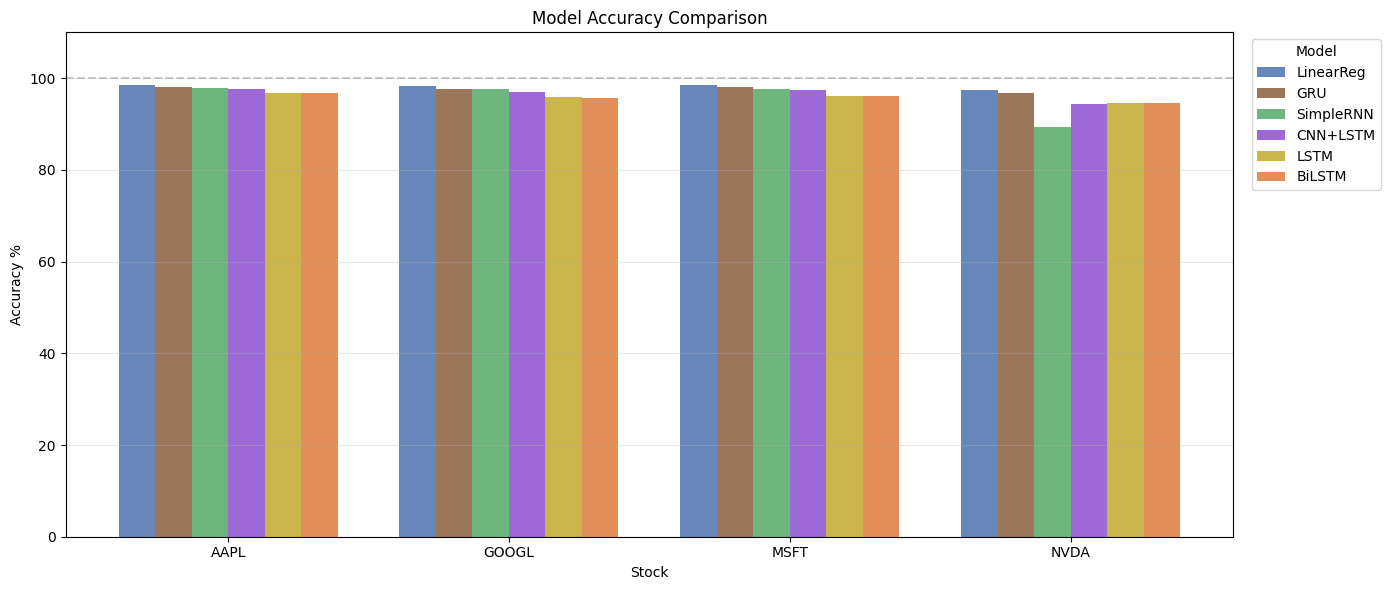

In [18]:
model_names = all_results_df["Model"].unique()
stock_list  = all_results_df["Stock"].unique()

x      = np.arange(len(stock_list))
width  = 0.13
colors = ["#4C72B0", "#8B5E3C", "#55A868", "#8B4FCF", "#C4A82D", "#E07B3A"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    accs = []
    for stock in stock_list:
        row = all_results_df[
            (all_results_df["Model"] == name) &
            (all_results_df["Stock"] == stock)
        ]["Accuracy %"]
        accs.append(row.values[0] if len(row) else 0)

    offset = (i - len(model_names) / 2) * width + width / 2
    ax.bar(x + offset, accs, width, label=name, color=color, alpha=0.85)

ax.set_xlabel("Stock")
ax.set_ylabel("Accuracy %")
ax.set_title("Model Accuracy Comparison")
ax.set_xticks(x)
ax.set_xticklabels(stock_list)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 110)
ax.axhline(y=100, color="gray", linestyle="--", alpha=0.4)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## Prediction Result

This graph shows the real price and the predicted future price using LSTM.

Blue = real price
Orange = predicted future

[*********************100%***********************]  1 of 1 completed


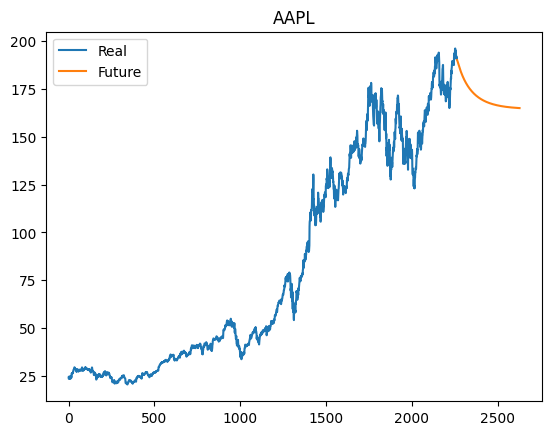

[*********************100%***********************]  1 of 1 completed


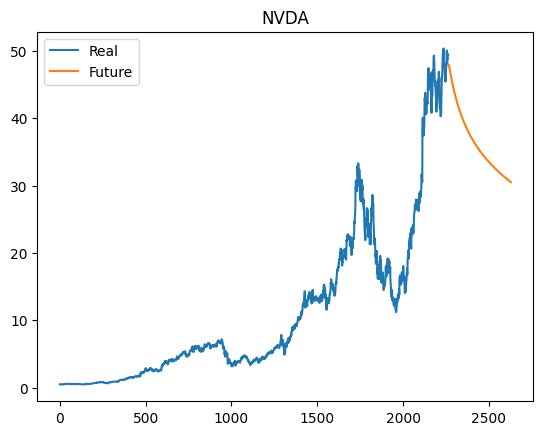

[*********************100%***********************]  1 of 1 completed


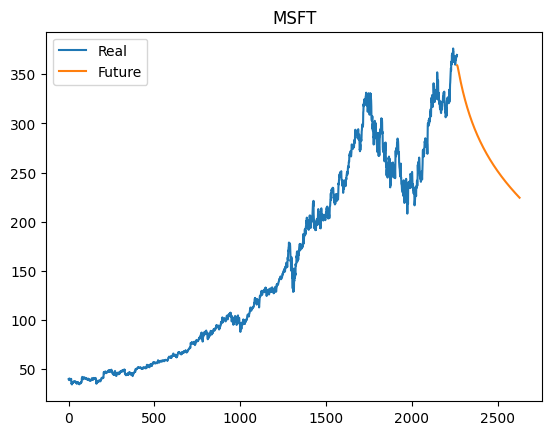

[*********************100%***********************]  1 of 1 completed


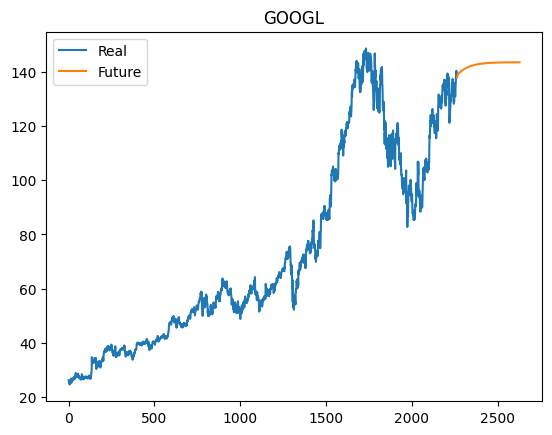

In [19]:
for symbol in stocks:

    df = yf.download(symbol, start=start_date, end=end_date)
    df = df[["Close"]]
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df.values)

    X = []
    y = []

    for i in range(time_step, len(scaled)):
        X.append(scaled[i-time_step:i, 0])
        y.append(scaled[i, 0])

    X = np.array(X)
    y = np.array(y)

    X = X.reshape(X.shape[0], X.shape[1], 1)

    model_f = Sequential()
    model_f.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
    model_f.add(LSTM(50))
    model_f.add(Dense(1))
    model_f.compile(optimizer="adam", loss="mean_squared_error")

    model_f.fit(X, y, epochs=5, batch_size=32, verbose=0)

    last_data = scaled[-time_step:]
    temp      = last_data.tolist()
    future    = []

    for i in range(future_days):
        x_in = np.array(temp[-time_step:]).reshape(1, time_step, 1)
        pred = model_f.predict(x_in, verbose=0)
        temp.append(pred[0].tolist())
        future.append(pred[0])

    future = scaler.inverse_transform(future)

    future_plot          = np.empty((len(df) + future_days, 1))
    future_plot[:]       = np.nan
    future_plot[len(df):] = future

    plt.figure()
    plt.plot(df.values,   label="Real")
    plt.plot(future_plot, label="Future")
    plt.title(symbol)
    plt.legend()
    plt.show()


# Model Evaluation

This project uses multiple models to predict stock prices.

Evaluation metrics:

MAE = Mean Absolute Error
RMSE = Root Mean Square Error
R2 = R squared score
Accuracy = custom accuracy formula

Formula:

Accuracy = 100 - (MAE / mean price * 100)

Stocks used:

AAPL
NVDA
MSFT
GOOGL

Dataset:
Yahoo Finance

Period:
2015-2023

Prediction:
Future 1 year